In [1]:
from pathlib import Path
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import sys

Jeu de donnée

- [Dataset](https://drive.google.com/file/d/1C-tYJcgJDx5AuF7_oz7U4bbY0PERiFLo/view?usp=sharing)
- [Description](https://drive.google.com/file/d/1VSRPKK6ys0Kn3gSYDHgrQogdBAHXcEKg/view?usp=sharing)

In [2]:
ROOT = (Path.cwd().parent).resolve()
# Ajouter le dossier 'src' au chemin de recherche des modules
src_path = ROOT / "src"
sys.path.append(str(src_path))

# DATA = (Path(__file__).parent / "data"/ "water_portability.csv").resolve()
# Path.cwd() cible le dossier racine où tourne ton notebook
DATA = (Path.cwd().parent / "data" / "water_potability.csv").resolve()

if DATA.exists():
    print(f"✅ Fichier trouvé ! Chemin : {DATA}")
else:
    print(f"❌ Erreur : Le fichier n'existe pas à l'emplacement {DATA}")

✅ Fichier trouvé ! Chemin : /home/coule/Documents/projets/waterflow/data/water_potability.csv


In [3]:
import cleaning_utils as clean
import analysis_utils as analyse

In [4]:
data = pd.read_csv(DATA)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


## Définition de la target

In [5]:
TARGET = "Potability"

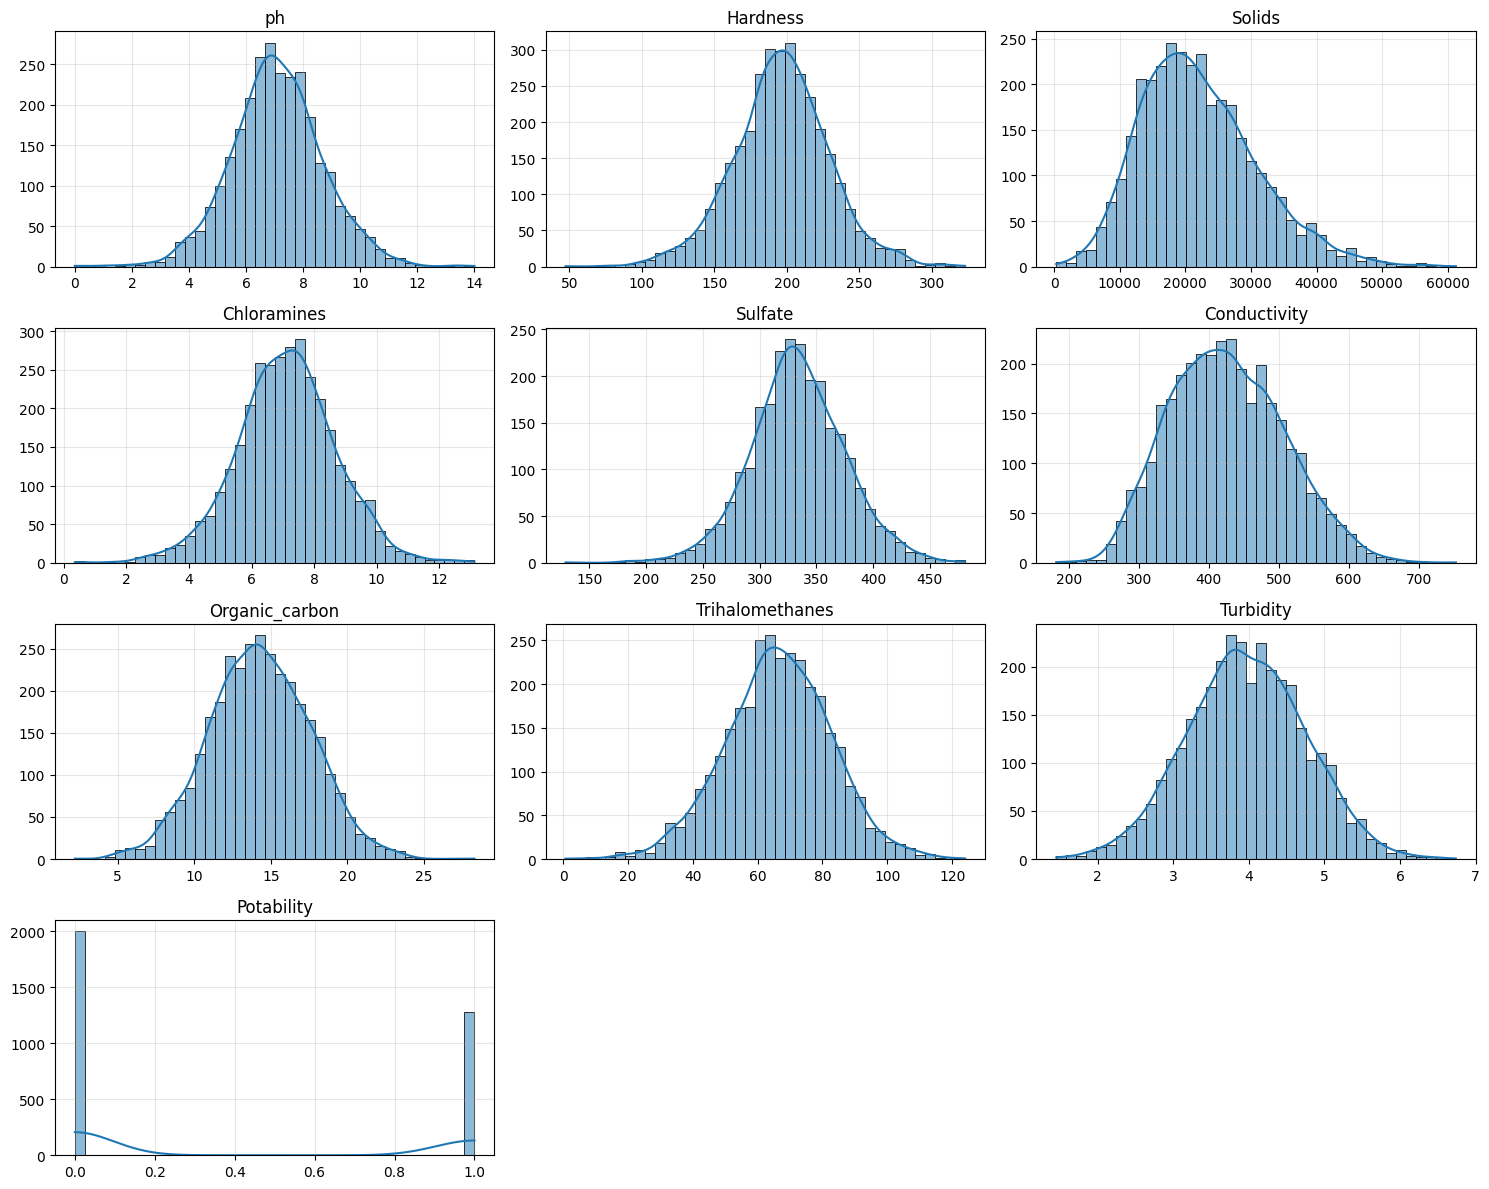

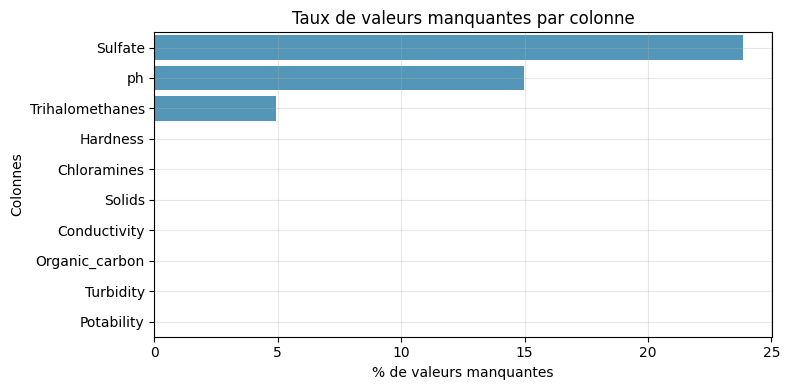

In [6]:
# 1. Chargement et Exploration Initiale (EDA)
df = data
missing_info = clean.get_missing_summary(df)
special_cols = clean.get_special_columns(df)

# Visualisations rapides
analyse.plot_numeric_histograms(df)
analyse.plot_missing_bar(df)

In [8]:
# 2. Premier nettoyage global & Split (Anti-Leakage)
df_normalized = clean.normalize_text_features(df)

X = df_normalized.drop(columns=[TARGET])
y = df_normalized[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Pipeline de transformation
config_nettoyage = {
    "drop_na_threshold": 0.50,
    "binary_cols": special_cols["boolean"],
    "numeric_median_cols": special_cols["numeric"],
    "replace_maps": {"statut": {"non-actif": 0, "actif": 1}}
}

# On "fit" et "transform" sur le Train, on "transform" uniquement sur le Test
X_train_clean, stats_train = clean.fit_transform_clean(X_train, config_nettoyage)
X_test_clean = clean.transform_clean(X_test, stats_train, config_nettoyage)

# 4. Modélisation et Évaluation
grid = {"n_estimators": [50, 100, 200], "max_depth": [5, 10, None]}

resultats = analyse.evaluate_regression_model(
    algo=RandomForestRegressor(random_state=42),
    param_grid=grid,
    X_train=X_train_clean,
    y_train=y_train,
    X_test=X_test_clean,
    y_test=y_test,
    search_type='random'
)

/home/coule/Documents/projets/waterflow/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


=== Modèle : RandomForestRegressor ===
Meilleurs paramètres : {'n_estimators': 200, 'max_depth': 10}
R2 (Test) : 0.1182
RMSE : 0.45
MAE  : 0.42
